# 🚀 Faster R-CNN voor Recipes

In dit notebook ga ik stap voor stap een Faster RCNN model trainen

!pip3 install torch torchvision

!pip3 install pycocotools

!pip3 install matplotlib Pillow


In [41]:
import os

print ('📁 Directory of dataset:\n')
for root, dirs, files in os.walk('./dataset'):
    level = root.replace('./dataset', '').count(os.sep)
    indent = ' ' * level * 4
    print(f'{indent} 📂 {os.path.basename(root)}/')
    if level < 2:
        for file in files[:5]:
            print(f'{indent}  📄 {file}')
        if len(files) > 5:
            print(f'{indent}  ... ({len(files) - 5} more files)')

📁 Directory of dataset:

 📂 dataset/
  📄 .DS_Store
     📂 apples/
      📄 README.roboflow.txt
      📄 README.dataset.txt
      📄 .DS_Store
         📂 valid/
         📂 test/
         📂 train/


In [42]:
import json

ann_path = './dataset/apples/train/_annotations.coco.json'

with open(ann_path, 'r') as f:
    coco_data = json.load(f)

print("📊 Dataset overview:")
print(f"  🖼️  Number of images : {len(coco_data['images'])}")
print(f"  🏷️  Number of annotations   : {len(coco_data['annotations'])}")
print(f"  🎯 Number of classes      : {len(coco_data['categories'])}")

print('\n🎯 Classes in dataset:')
for category in coco_data['categories']:
    print(f"  📌 ID {category['id']}: {category['name']}")

NUM_CLASSES = len(coco_data['categories'])
print(f"\n✅ NUM_CLASSES set to {NUM_CLASSES}")

📊 Dataset overview:
  🖼️  Number of images : 489
  🏷️  Number of annotations   : 2013
  🎯 Number of classes      : 3

🎯 Classes in dataset:
  📌 ID 0: apples
  📌 ID 1: apple
  📌 ID 2: damaged_apple

✅ NUM_CLASSES set to 3


/var/folders/qd/j2xpq0tj21s3cx2mvym58cyh0000gn/T/ipykernel_14096/2979258511.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', NUM_CLASSES)
/var/folders/qd/j2xpq0tj21s3cx2mvym58cyh0000gn/T/ipykernel_14096/2979258511.py:37: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jaycey/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


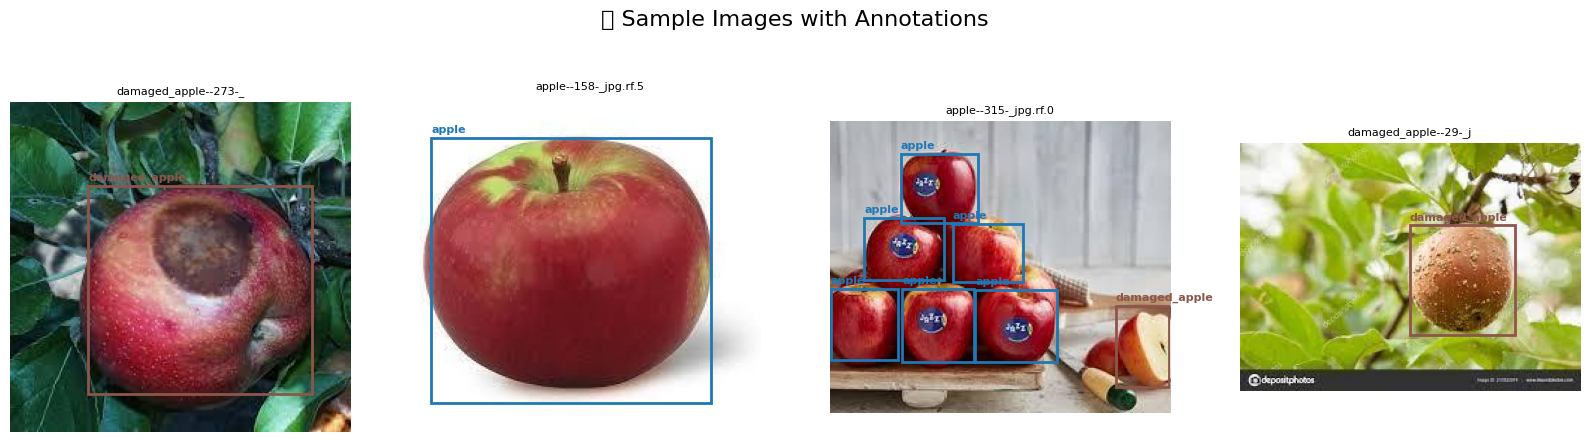

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

ann_by_image = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    ann_by_image.setdefault(img_id, []).append(ann)

category_names = {cat['id']: cat['name'] for cat in coco_data['categories']}
colors = plt.cm.get_cmap('tab10', NUM_CLASSES)

sample_images = random.sample(coco_data['images'], min(4, len(coco_data['images'])))

fig, axes = plt.subplots(1, len(sample_images), figsize=(16, 5))
if len(sample_images) == 1:
    axes = [axes]

for ax, image_info in zip(axes, sample_images):
    image_path = os.path.join('./dataset/apples/train', image_info['file_name'])
    image = Image.open(image_path).convert('RGB')
    ax.imshow(image)
    ax.set_title(image_info['file_name'][:20], fontsize=8)
    ax.axis('off')

    for ann in ann_by_image.get(image_info['id'], []):
        x, y, w, h = ann['bbox']
        category_id = ann['category_id']
        color = colors(category_id - 1)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        ax.text(x, y - 4, category_names[category_id], color=color, fontsize=8, fontweight='bold')

plt.suptitle('📸 Sample Images with Annotations', fontsize=16)
plt.tight_layout()
plt.show()

In [44]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    return model

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print (f"💻 Using device: {device}")

if device.type == 'cpu':
    print("⚠️  No GPU found - training will be slower.")
else:
    print("🚀 GPU detected - training will be faster.")

model = get_model(NUM_CLASSES).to(device)
print(f"\n✅ Model initialized for {NUM_CLASSES} classes (+1 background).")

💻 Using device: mps
🚀 GPU detected - training will be faster.

✅ Model initialized for 3 classes (+1 background).


In [45]:
from torch.utils.data import DataLoader
import torchvision.transforms as T
from pycocotools.coco import COCO

class COCODataset(torch.utils.data.Dataset):
    def __init__(self, image_folder, ann_file):
        self.coco = COCO(ann_file)
        self.ids = list(self.coco.imgs.keys())
        self.image_folder = image_folder
        self.transform = T.ToTensor()

    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        image_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)
        image_info = self.coco.loadImgs(image_id)[0]

        image = Image.open(os.path.join(self.image_folder, image_info['file_name'])).convert('RGB')

        boxes, labels = [], []
        for ann in anns:
            x,y, w, h = ann['bbox']
            if w > 0 and h > 0:
                boxes.append([x, y, x + w, y + h])
                labels.append(ann['category_id'])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor(image_id)
        }
        return self.transform(image), target
    
train_dataset = COCODataset(
    image_folder='./dataset/apples/train',
    ann_file='./dataset/apples/train/_annotations.coco.json'
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

print(f'✅ Dataset loaded!')
print(f'  🖼️  Training images : {len(train_dataset)}')
print(f' 📦 Batches per epoch : {len(train_loader)}')

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Dataset loaded!
  🖼️  Training images : 489
 📦 Batches per epoch : 245


In [ ]:
NUM_EPOCHS = 10

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

loss_history = []

print(f'🏋️ Training started for {NUM_EPOCHS} epochs!\n')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'✅ Epoch {epoch+1} completed! Average Loss: {avg_loss:.4f}\n')

torch.save(model.state_dict(), 'faster_rcnn_model.pth')
print('💾 Model training completed and saved as faster_rcnn_model.pth')


🏋️ Training started for 10 epochs!



In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='royalblue', linewidth=2)
plt.title('Training Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'📉 Loss decreased from {loss_history[0]:.4f} to {loss_history[-1]:.4f}')

In [ ]:
def predict_and_show(image_path, model, device, categories, threshhold=0.5):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image_tensor = T.ToTensor()(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)[0]

    keep = outputs['scores'] > threshhold
    boxes = outputs['boxes'][keep].cpu()
    labels = outputs['labels'][keep].cpu()
    scores = outputs['scores'][keep].cpu()

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image)
    colors = plt.cm.get_cmap('tab10', len(categories))

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        category_name = categories.get(label.item(), str(label.item()))
        color = colors(label.item() - 1)
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 6, f'{category_name} {score:.2f}', color='white', fontsize=9, fontweight='bold', bbox=dict(facecolor=color, alpha=0.7, pad=2))

    ax.set_title(f'{len(boxes)} objects detected (threshhold={threshhold})', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

categories = {category['id']: category['name'] for category in coco_data['categories']}

test_images = [f for f in os.listdir('./dataset/apples/test') if f.endswith(('.jpg', '.png', '.jpeg'))]

if test_images:
    test_image_path = os.path.join('./dataset/apples/test', test_images[0])
    predict_and_show(test_image_path, model, device, categories, threshhold=0.5)
else:
    print('⚠️  No test images found in ./dataset/apples/test/')